In [ ]:
# Data manipulation
import numpy as np
import pandas as pd

# Ignore warnings
#import warnings
#from pandas.errors import SettingWithCopyWarning

# Data visualization
import matplotlib
import seaborn as sns
import matplotlib.pyplot as plt
#from wordcloud import WordCloud, STOPWORDS

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
rating_data = pd.io.parsers.read_csv('/content/drive/MyDrive/Colab Notebooks/ratings.dat',
    names=['user_id', 'movie_id', 'rating', 'time'],
    engine='python', delimiter='::')

movie_data = pd.io.parsers.read_csv('/content/drive/MyDrive/Colab Notebooks/movies.dat',
    names=['movie_id', 'title', 'genre'],
    engine='python', delimiter='::',encoding='latin-1')

In [ ]:
rating_data.head()

,user_id,movie_id,rating,time
0,1,1193,5,978300760
1,1,661,3,978302109
2,1,914,3,978301968
3,1,3408,4,978300275
4,1,2355,5,978824291


In [ ]:
movie_data.head()

,movie_id,title,genre
0,1,Toy Story (1995),Animation|Children's|Comedy
1,2,Jumanji (1995),Adventure|Children's|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama
4,5,Father of the Bride Part II (1995),Comedy


EDA

In [ ]:
df1 = movie_data
df2 = rating_data

In [ ]:
df = pd.merge(df1, df2, on="movie_id", how="left")

In [ ]:
df1=df.copy()

In [ ]:
df.head(10)

,movie_id,title,genre,user_id,rating,time
0,1,Toy Story (1995),Animation|Children's|Comedy,1.0,5.0,978824268.0
1,1,Toy Story (1995),Animation|Children's|Comedy,6.0,4.0,978237008.0
2,1,Toy Story (1995),Animation|Children's|Comedy,8.0,4.0,978233496.0
3,1,Toy Story (1995),Animation|Children's|Comedy,9.0,5.0,978225952.0
4,1,Toy Story (1995),Animation|Children's|Comedy,10.0,5.0,978226474.0
5,1,Toy Story (1995),Animation|Children's|Comedy,18.0,4.0,978154768.0
6,1,Toy Story (1995),Animation|Children's|Comedy,19.0,5.0,978555994.0
7,1,Toy Story (1995),Animation|Children's|Comedy,21.0,3.0,978139347.0
8,1,Toy Story (1995),Animation|Children's|Comedy,23.0,4.0,978463614.0
9,1,Toy Story (1995),Animation|Children's|Comedy,26.0,3.0,978130703.0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000386 entries, 0 to 1000385
Data columns (total 6 columns):
 #   Column    Non-Null Count    Dtype  
---  ------    --------------    -----  
 0   movie_id  1000386 non-null  int64  
 1   title     1000386 non-null  object 
 2   genre     1000386 non-null  object 
 3   user_id   1000209 non-null  float64
 4   rating    1000209 non-null  float64
 5   time      1000209 non-null  float64
dtypes: float64(3), int64(1), object(2)
memory usage: 45.8+ MB


In [ ]:
df.isnull().sum()

movie_id      0
title         0
genre         0
user_id     177
rating      177
time        177
dtype: int64

In [ ]:
df = df.dropna()

In [ ]:
df.describe()

,movie_id,user_id,rating,time
count,1.000209e+06,1.000209e+06,1.000209e+06,1.000209e+06
mean,1.865540e+03,3.024512e+03,3.581564e+00,9.722437e+08
std,1.096041e+03,1.728413e+03,1.117102e+00,1.215256e+07
min,1.000000e+00,1.000000e+00,1.000000e+00,9.567039e+08
25%,1.030000e+03,1.506000e+03,3.000000e+00,9.653026e+08
50%,1.835000e+03,3.070000e+03,4.000000e+00,9.730180e+08
75%,2.770000e+03,4.476000e+03,4.000000e+00,9.752209e+08
max,3.952000e+03,6.040000e+03,5.000000e+00,1.046455e+09


In [ ]:
df_sample=df

In [ ]:
average_ratings = df_sample.groupby(['movie_id', 'title'])['rating'].mean().reset_index()
average_ratings = df.groupby(['movie_id', 'title'])['rating'].mean().reset_index()
average_ratings = average_ratings.rename(columns={'rating': 'average_rating'})
sorted_movies = average_ratings.sort_values(by='average_rating', ascending=False)
print(sorted_movies)

      movie_id                                      title  average_rating
926        989  Schlafes Bruder (Brother of Sleep) (1995)             5.0
3635      3881                   Bittersweet Motel (2000)             5.0
1652      1830                    Follow the Bitch (1998)             5.0
3152      3382                     Song of Freedom (1936)             5.0
744        787         Gate of Heavenly Peace, The (1995)             5.0
...        ...                                        ...             ...
774        826                           Diebinnen (1995)             1.0
3006      3228                      Wirey Spindell (1999)             1.0
2638      2845                          White Boys (1999)             1.0
2989      3209                Loves of Carmen, The (1948)             1.0
137        142                    Shadows (Cienie) (1988)             1.0

[3706 rows x 3 columns]


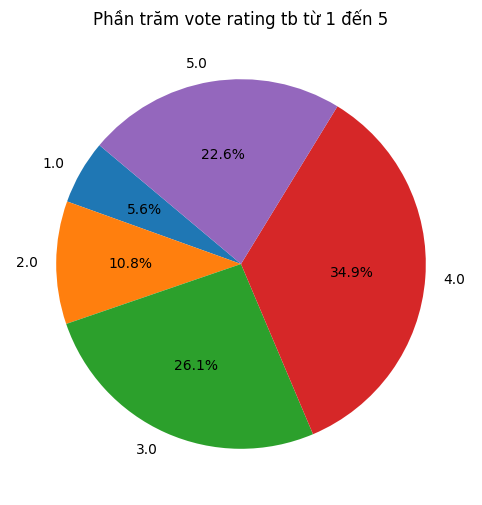

In [ ]:
rating_counts = df['rating'].value_counts().sort_index()
total_people = rating_counts.sum()
percentages = (rating_counts / total_people) * 100
plt.figure(figsize=(8, 6))
plt.pie(percentages, labels=percentages.index.map(str), autopct='%1.1f%%', startangle=140)
plt.title('Phần trăm vote rating tb từ 1 đến 5')
plt.show()

In [ ]:
average_times = df.groupby(['movie_id', 'title'])['time'].mean().reset_index()
average_times = average_times.rename(columns={'time': 'average_time'})
sorted_movies = average_times.sort_values(by='average_time', ascending=False)
print(sorted_movies)

      movie_id                                        title  average_time
2039      2226                             Ring, The (1927)  1.036452e+09
2394      2592                        Joyriders, The (1999)  1.035153e+09
3089      3315                       Happy Go Lovely (1951)  1.033002e+09
3065      3291                                 Trois (2000)  1.029337e+09
636        658                       Billy's Holiday (1995)  1.025574e+09
...        ...                                          ...           ...
1688      1868                            Truce, The (1996)  9.598074e+08
2017      2198                           Modulations (1998)  9.591460e+08
2638      2845                            White Boys (1999)  9.581531e+08
3367      3607                     One Little Indian (1973)  9.577566e+08
2702      2909  Five Wives, Three Secretaries and Me (1998)  9.572734e+08

[3706 rows x 3 columns]


In [ ]:
df['year'] = df['title'].str.extract(r'\((\d{4})\)').astype('int64')
df.head(10)

,movie_id,title,genre,user_id,rating,time,year
0,1,Toy Story (1995),Animation|Children's|Comedy,1.0,5.0,978824268.0,1995
1,1,Toy Story (1995),Animation|Children's|Comedy,6.0,4.0,978237008.0,1995
2,1,Toy Story (1995),Animation|Children's|Comedy,8.0,4.0,978233496.0,1995
3,1,Toy Story (1995),Animation|Children's|Comedy,9.0,5.0,978225952.0,1995
4,1,Toy Story (1995),Animation|Children's|Comedy,10.0,5.0,978226474.0,1995
5,1,Toy Story (1995),Animation|Children's|Comedy,18.0,4.0,978154768.0,1995
6,1,Toy Story (1995),Animation|Children's|Comedy,19.0,5.0,978555994.0,1995
7,1,Toy Story (1995),Animation|Children's|Comedy,21.0,3.0,978139347.0,1995
8,1,Toy Story (1995),Animation|Children's|Comedy,23.0,4.0,978463614.0,1995
9,1,Toy Story (1995),Animation|Children's|Comedy,26.0,3.0,978130703.0,1995


In [ ]:
min_year = df['year'].min()
max_year = df['year'].max()

print(f"Năm đầu tiên trong data: {min_year}")
print(f"Năm cuối cùng trong data: {max_year}")

Năm đầu tiên trong data: 1919
Năm cuối cùng trong data: 2000


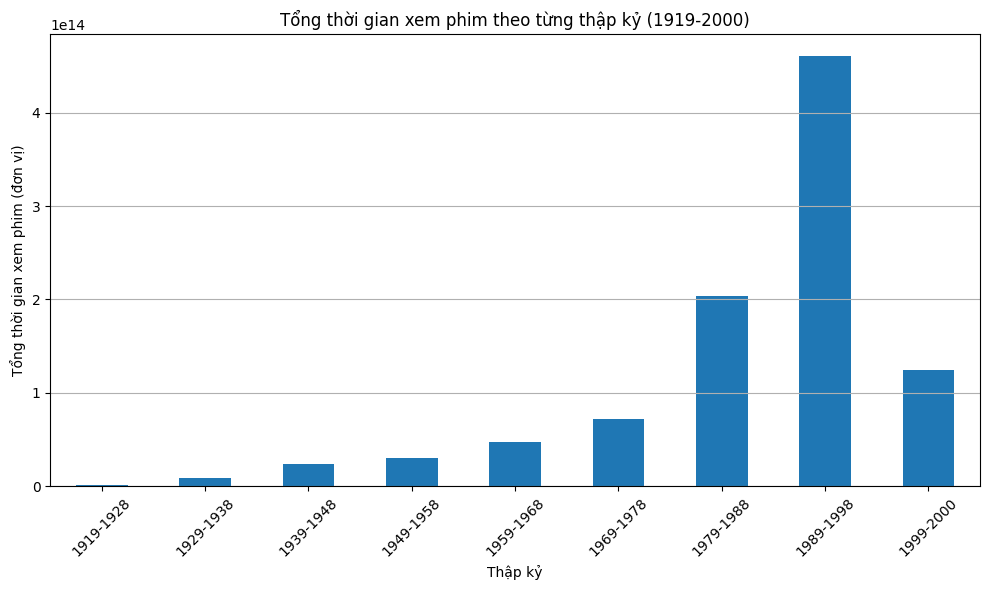

In [ ]:
df['year_group'] = ((df['year'] - 1919) // 10) * 10 + 1919
time_by_decade = df.groupby('year_group')['time'].sum()

# Tạo nhãn cho trục x
decade_labels = [f"{decade}-{decade+9}" for decade in range(1919, 2000, 10)]
decade_labels[-1] = "1999-2000"  # Thay đổi giá trị cuối cùng của decade_labels

# Vẽ biểu đồ cột
plt.figure(figsize=(10, 6))
time_by_decade.plot(kind='bar')
plt.title('Tổng thời gian xem phim theo từng thập kỷ (1919-2000)')
plt.xlabel('Thập kỷ')
plt.ylabel('Tổng thời gian xem phim (đơn vị)')
plt.xticks(range(len(time_by_decade.index)), decade_labels, rotation=45)
plt.grid(axis='y')
plt.tight_layout()
plt.show()

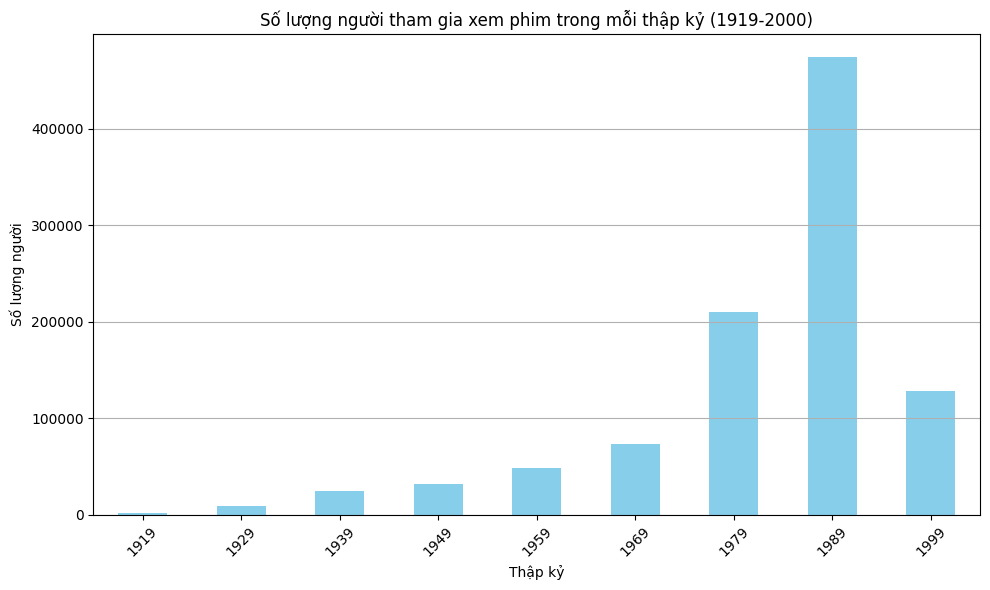

In [ ]:
df['decade'] = ((df['year'] - 1919) // 10) * 10 + 1919

# Đếm số lượng người trong mỗi thập kỷ
people_per_decade = df.groupby('decade')['user_id'].count()

# Vẽ biểu đồ cột
plt.figure(figsize=(10, 6))
people_per_decade.plot(kind='bar', color='skyblue')
plt.title('Số lượng người tham gia xem phim trong mỗi thập kỷ (1919-2000)')
plt.xlabel('Thập kỷ')
plt.ylabel('Số lượng người')
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.tight_layout()
plt.show()

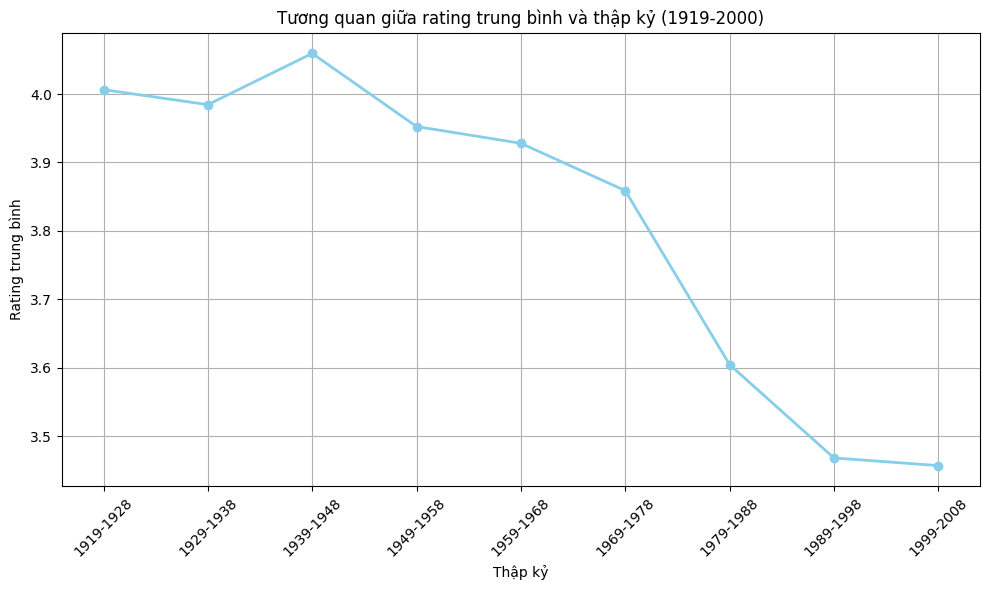

In [ ]:
# Tính toán 'year_group' và rating trung bình theo thập kỷ
df['year_group'] = ((df['year'] - 1919) // 10) * 10 + 1919
rating_by_decade = df.groupby('year_group')['rating'].mean()

# Tạo biểu đồ đường
plt.figure(figsize=(10, 6))
plt.plot(rating_by_decade.index, rating_by_decade.values, marker='o', linestyle='-', color='skyblue', linewidth=2)
plt.title('Tương quan giữa rating trung bình và thập kỷ (1919-2000)')
plt.xlabel('Thập kỷ')
plt.ylabel('Rating trung bình')

# Định nghĩa nhãn trục x tùy chỉnh
decade_labels = [f"{decade}-{decade+9}" for decade in rating_by_decade.index]
plt.xticks(rating_by_decade.index, decade_labels, rotation=45)

plt.grid(True)
plt.tight_layout()
plt.show()

-Gia tang dan so, nguoi xem tang -> luot tham gia danh gia tang , thoi gian xem tang
-Nhieu luot danh gia hon -> rating trung binh giam

In [ ]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000386 entries, 0 to 1000385
Data columns (total 6 columns):
 #   Column    Non-Null Count    Dtype  
---  ------    --------------    -----  
 0   movie_id  1000386 non-null  int64  
 1   title     1000386 non-null  object 
 2   genre     1000386 non-null  object 
 3   user_id   1000209 non-null  float64
 4   rating    1000209 non-null  float64
 5   time      1000209 non-null  float64
dtypes: float64(3), int64(1), object(2)
memory usage: 45.8+ MB


In [ ]:
df1['movie_id'] = df1['movie_id'].astype(str)

In [ ]:
df1['year'] = df1['title'].str.extract(r'\((\d{4})\)').astype('int64')

In [ ]:
#df1["year"] = pd.to_datetime(df1["year"])

In [ ]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000386 entries, 0 to 1000385
Data columns (total 7 columns):
 #   Column    Non-Null Count    Dtype  
---  ------    --------------    -----  
 0   movie_id  1000386 non-null  object 
 1   title     1000386 non-null  object 
 2   genre     1000386 non-null  object 
 3   user_id   1000209 non-null  float64
 4   rating    1000209 non-null  float64
 5   time      1000209 non-null  float64
 6   year      1000386 non-null  int64  
dtypes: float64(3), int64(1), object(3)
memory usage: 53.4+ MB


In [ ]:
df1.head(10)

,movie_id,title,genre,user_id,rating,time,year
0,1,Toy Story (1995),Animation|Children's|Comedy,1.0,5.0,978824268.0,1995
1,1,Toy Story (1995),Animation|Children's|Comedy,6.0,4.0,978237008.0,1995
2,1,Toy Story (1995),Animation|Children's|Comedy,8.0,4.0,978233496.0,1995
3,1,Toy Story (1995),Animation|Children's|Comedy,9.0,5.0,978225952.0,1995
4,1,Toy Story (1995),Animation|Children's|Comedy,10.0,5.0,978226474.0,1995
5,1,Toy Story (1995),Animation|Children's|Comedy,18.0,4.0,978154768.0,1995
6,1,Toy Story (1995),Animation|Children's|Comedy,19.0,5.0,978555994.0,1995
7,1,Toy Story (1995),Animation|Children's|Comedy,21.0,3.0,978139347.0,1995
8,1,Toy Story (1995),Animation|Children's|Comedy,23.0,4.0,978463614.0,1995
9,1,Toy Story (1995),Animation|Children's|Comedy,26.0,3.0,978130703.0,1995


In [ ]:
import plotly.graph_objects as go

In [ ]:
def plot_timeseries_by_level(
    df: pd.DataFrame,
    key_level = ["genre"],
    target_var = "rating",
    start_year = 1919,
    end_year = 2000,
    hover_mode = "x unified",
    agg_function = "mean",
):
    fig = go.Figure(data=[])

    for key, df_group in df.groupby(key_level):
        df_group = df_group[
            df_group["year"].between(start_year, end_year)
        ]
        df_group = df_group.groupby([*key_level, "year"]).agg({target_var: agg_function}).reset_index()

        fig.add_trace(
            go.Scatter(
                x = df_group["year"],
                y = df_group[target_var],
                name = str(key),
                connectgaps = False,
                mode = "lines",
            )
        )
    # remove square bracket in title
    title_key_level = str(key_level)
    for reg in ["'", "[", "]"]:
        title_key_level = title_key_level.replace(reg, " ")

    fig.update_layout(
        title=f"{target_var} data of each {title_key_level} from {start_year} to {end_year}",
        hovermode=hover_mode
    )
    fig.show()


def plot_distribution_by_level(
    df: pd.DataFrame,
    key_level = ["genre"],
    target_var = "rating",
    start_year = 1919,
    end_year = 2000,
    title_key_level = None,
    hist_function = "count",
    hover_mode = "x unified"
):
    fig = go.Figure()

    for key, df_group in df.groupby(key_level):
        df_group = df_group[
            df_group["year"].between(start_year, end_year)
        ]
        df_group = df_group.groupby([*key_level, "year"])[target_var].sum().reset_index()

        fig.add_trace(
            go.Histogram(
                x = df_group[target_var],
                name = str(key),
                histfunc = hist_function,
            )
        )

    if title_key_level is None:
        # remove square bracket in title
        title_key_level = str(key_level)
        for reg in ["'", "[", "]"]:
            title_key_level = title_key_level.replace(reg, " ")

        fig.update_layout(
            title=f"{target_var} data of each {title_key_level} from {start_year} to {end_year}",
            hovermode=hover_mode
        )
    else:
        fig.update_layout(
            title=f"{title_key_level} from {start_year} to {end_year}",
            hovermode=hover_mode
        )

    fig.update_layout(barmode='group') # or relative
    fig.show()

In [ ]:
plot_distribution_by_level(df1,hover_mode = None)

In [ ]:
df1['primary_genre'] = df1['genre'].apply(lambda x: x.split('|')[0])
df1.head(10)

,movie_id,title,genre,user_id,rating,time,year,primary_genre
0,1,Toy Story (1995),Animation|Children's|Comedy,1.0,5.0,978824268.0,1995,Animation
1,1,Toy Story (1995),Animation|Children's|Comedy,6.0,4.0,978237008.0,1995,Animation
2,1,Toy Story (1995),Animation|Children's|Comedy,8.0,4.0,978233496.0,1995,Animation
3,1,Toy Story (1995),Animation|Children's|Comedy,9.0,5.0,978225952.0,1995,Animation
4,1,Toy Story (1995),Animation|Children's|Comedy,10.0,5.0,978226474.0,1995,Animation
5,1,Toy Story (1995),Animation|Children's|Comedy,18.0,4.0,978154768.0,1995,Animation
6,1,Toy Story (1995),Animation|Children's|Comedy,19.0,5.0,978555994.0,1995,Animation
7,1,Toy Story (1995),Animation|Children's|Comedy,21.0,3.0,978139347.0,1995,Animation
8,1,Toy Story (1995),Animation|Children's|Comedy,23.0,4.0,978463614.0,1995,Animation
9,1,Toy Story (1995),Animation|Children's|Comedy,26.0,3.0,978130703.0,1995,Animation


In [ ]:
plot_timeseries_by_level(df1,key_level = ["primary_genre"],target_var = "rating",hover_mode = None)

In [ ]:
plot_distribution_by_level(df1,key_level = ["primary_genre"],target_var = "rating",hover_mode = None)

In [ ]:
plot_timeseries_by_level(df1,key_level = ["primary_genre"],target_var = "time",hover_mode = None)

In [ ]:
plot_distribution_by_level(df1,key_level = ["primary_genre"],target_var = "time",hover_mode = None)

SVD

In [ ]:
users  = rating_data['user_id'].unique()   # list all users
movies = movie_data['movie_id'].unique()   # lisr all movie

In [ ]:
rating_matrix = np.zeros(shape=(max(users), max(movies)), dtype=np.uint8)

rating_matrix[rating_data.user_id.values - 1, rating_data.movie_id.values - 1] = rating_data.rating.values

print(rating_matrix.shape)
print(rating_matrix[:20,:20])

(6040, 3952)
[[5 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 2 0 0 0 0 0 0 0 0 0 3 0 0 0 0]
 [4 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 4 0 0 0]
 [0 0 0 0 0 4 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [4 0 0 3 0 0 0 0 0 0 0 0 0 4 0 4 4 0 0 0]
 [5 0 0 0 0 0 0 0 0 0 0 0 0 0 0 4 0 0 0 0]
 [5 5 0 0 0 0 4 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 3 0 0 0 0 0 0 0 3 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 4 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [4 2 0 0 0 0 0 0 0 5 0 0 0 0 0 0 4 0 0 0]
 [5 0 0 0 0 0 0 0 0 5 0 0 0 0 0 0 4 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]]


In [ ]:
def truncated_svd(data,percent):
    normaliztion_matrix = data - np.mean(data, axis=1).reshape(-1, 1)
    U, S, VT = np.linalg.svd(normaliztion_matrix,full_matrices = False)
    Sigma = np.zeros_like(normaliztion_matrix, dtype=float)
    Sigma[:S.shape[0], :S.shape[0]] = np.diag(S)

    S_r = [i for i in S if i !=0]
    sum_r=0
    for i in S_r:
        sum_r = sum_r + i**2

    sum_k=0
    for i in range(len(S_r)):
        sum_k = sum_k + S_r[i]**2
        if sum_k/sum_r > percent:
            return U[:,:i],Sigma[:i,:i],VT[:i,:],i

In [ ]:
def get_unrated_movie(user_id,data):
    unrated_movie = np.where(data[user_id-1] == 0)[0]
    return unrated_movie

In [ ]:
def guess_rating(user_id,U,S,VT,unrated_movies,top_indexes,i):
    list_rating = []
    for movie in unrated_movies:
        rating = {"id": movie,"rating":U[user_id,:i]@S@VT[:,movie]}
        list_rating.append(rating)
    sorted_list = sorted(list_rating, key=lambda x: x['rating'],reverse=True)
    return sorted_list[:top_indexes]

In [ ]:
def print_movies(user_id,movie_data, movie_id):
    print(f'Recommendations for user {user_id}: \n')
    for id in movie_id:
        movie_name = movie_data[movie_data['movie_id'] == (id)]['title'].values
        movie_genre = movie_data[movie_data['movie_id'] == (id)]['genre'].values
        if len(movie_name) > 0:
            print(f"Movie: {movie_name[0]}")
            print(f"\tGenre: {movie_genre[0]}\n")

In [ ]:
def cosine_similarity(data, movie_id, top):
    movie_columns = data[:,movie_id]
    norm_data = np.linalg.norm(data.T, axis=1)
    cosine = np.dot(movie_columns,data)/(np.linalg.norm(movie_columns)*norm_data)
    sorted = np.argsort(-cosine)
    sorted = np.delete(sorted, 0)
    return sorted[:top]

def recommend_similar_movie(VT,movie_id,top):
    similar_movie = []
    similar_movie.append(cosine_similarity(VT, movie_id, top))

    movie_name = movie_data[movie_data['movie_id'] == (movie_id)]['title'].values
    movie_genre = movie_data[movie_data['movie_id'] == (movie_id)]['genre'].values
    print(f'Similar movies to movie {movie_name[0]} - Genre: {movie_genre[0]}: \n')

    for id in np.unique(np.array(similar_movie).flatten()):
        similar_movie_name = movie_data[movie_data['movie_id'] == (id)]['title'].values
        similar_movie_genre = movie_data[movie_data['movie_id'] == (id)]['genre'].values

        if len(similar_movie_name) > 0:
            print(f"Movie: {similar_movie_name[0]}")
            print(f"\tGenre: {similar_movie_genre[0]}\n")

In [ ]:
U,S,VT,i = truncated_svd(rating_matrix,0.9)

In [ ]:
recommend_similar_movie(VT,345,5)

Similar movies to movie Adventures of Priscilla, Queen of the Desert, The (1994) - Genre: Comedy|Drama: 

Movie: Love & Human Remains (1993)
	Genre: Comedy

Movie: Eraser (1996)
	Genre: Action|Thriller

Movie: Microcosmos (Microcosmos: Le peuple de l'herbe) (1996)
	Genre: Documentary

Movie: Under the Rainbow (1981)
	Genre: Comedy

Movie: Two Jakes, The (1990)
	Genre: Drama



In [ ]:
def recommend_movie(user_id,data,top_indexes,genre=None,year=None):
    U,S,VT,i = truncated_svd(data,0.9)

    unrated_movies = get_unrated_movie(user_id,data)

    if genre is not None:
        genre_movies = movie_data[movie_data['genre'].str.contains(genre)].movie_id.values
        unrated_movies = np.intersect1d(unrated_movies,genre_movies)

    if year is not None:
        year_movies = movie_data[movie_data['title'].str.contains(year)].movie_id.values
        unrated_movies = np.intersect1d(unrated_movies,year_movies)

    list_rating = guess_rating(user_id,U,S,VT,unrated_movies,top_indexes,i)

    movie_id = []

    for dictionary in list_rating:
        movie_id.append(dictionary['id'])

    print_movies(user_id,movie_data,movie_id)

In [ ]:
recommend_movie(234,rating_matrix,10,genre="Action",year="1999")

Recommendations for user 234: 

Movie: World Is Not Enough, The (1999)
	Genre: Action|Thriller

Movie: Wing Commander (1999)
	Genre: Action|Sci-Fi

Movie: End of Days (1999)
	Genre: Action|Thriller

Movie: Deep Blue Sea (1999)
	Genre: Action|Sci-Fi|Thriller

Movie: Thomas Crown Affair, The (1999)
	Genre: Action|Thriller

Movie: In Too Deep (1999)
	Genre: Action|Thriller

Movie: Chill Factor (1999)
	Genre: Action|Thriller

Movie: Payback (1999)
	Genre: Action|Thriller

Movie: Inspector Gadget (1999)
	Genre: Action|Adventure|Children's|Comedy

Movie: Double Jeopardy (1999)
	Genre: Action|Thriller

